In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt


In [2]:
# EDIT if needed
DATA_ROOT = Path(r"W:\SRH study\Case Study 2\Offline Signature Verification\Datasets\signatures")
ORG_DIR  = DATA_ROOT / "full_org"
FORG_DIR = DATA_ROOT / "full_forg"

print("ORG exists:", ORG_DIR.exists(), ORG_DIR)
print("FORG exists:", FORG_DIR.exists(), FORG_DIR)

PAT_ORG  = re.compile(r"^original_(\d+)_(\d+)\.png$", re.IGNORECASE)
PAT_FORG = re.compile(r"^forgeries_(\d+)_(\d+)\.png$", re.IGNORECASE)

rows = []

def scan(folder: Path, label: str, pat: re.Pattern):
    for fp in folder.iterdir():
        if not fp.is_file():
            continue
        if fp.suffix.lower() != ".png":
            continue
        m = pat.match(fp.name)
        if not m:
            rows.append({"writer_id": None, "sample_id": None, "label": label, "path": str(fp), "filename_ok": False})
            continue
        rows.append({"writer_id": int(m.group(1)), "sample_id": int(m.group(2)), "label": label, "path": str(fp), "filename_ok": True})

scan(ORG_DIR,  "genuine", PAT_ORG)
scan(FORG_DIR, "forgery", PAT_FORG)

df = pd.DataFrame(rows)
valid = df[df["filename_ok"]].copy()

print("Total images:", len(valid))
print("Bad filenames:", (~df["filename_ok"]).sum())
print(valid["label"].value_counts())
print("Unique writers:", valid["writer_id"].nunique())
display(valid.head())


ORG exists: True W:\SRH study\Case Study 2\Offline Signature Verification\Datasets\signatures\full_org
FORG exists: True W:\SRH study\Case Study 2\Offline Signature Verification\Datasets\signatures\full_forg
Total images: 2640
Bad filenames: 0
label
genuine    1320
forgery    1320
Name: count, dtype: int64
Unique writers: 55


,writer_id,sample_id,label,path,filename_ok
0,10,1,genuine,W:\SRH study\Case Study 2\Offline Signature Ve...,True
1,10,10,genuine,W:\SRH study\Case Study 2\Offline Signature Ve...,True
2,10,11,genuine,W:\SRH study\Case Study 2\Offline Signature Ve...,True
3,10,12,genuine,W:\SRH study\Case Study 2\Offline Signature Ve...,True
4,10,13,genuine,W:\SRH study\Case Study 2\Offline Signature Ve...,True


In [3]:
def split_writers(valid_df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9
    writers = np.array(sorted(valid_df["writer_id"].unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(writers)

    n = len(writers)
    n_train = int(round(n * train_ratio))
    n_val   = int(round(n * val_ratio))

    train_w = writers[:n_train]
    val_w   = writers[n_train:n_train+n_val]
    test_w  = writers[n_train+n_val:]

    return set(train_w), set(val_w), set(test_w)

train_writers, val_writers, test_writers = split_writers(valid, seed=42)

print("Train writers:", len(train_writers))
print("Val writers:", len(val_writers))
print("Test writers:", len(test_writers))
print("Overlap train-val:", len(train_writers & val_writers))
print("Overlap train-test:", len(train_writers & test_writers))
print("Overlap val-test:", len(val_writers & test_writers))


Train writers: 38
Val writers: 8
Test writers: 9
Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


In [4]:
def build_pools(df_subset):
    genuine_by_writer = {}
    forgery_by_writer = {}
    for wid, group in df_subset.groupby("writer_id"):
        g = group[group["label"] == "genuine"]["path"].tolist()
        f = group[group["label"] == "forgery"]["path"].tolist()
        if g: genuine_by_writer[wid] = g
        if f: forgery_by_writer[wid] = f
    return genuine_by_writer, forgery_by_writer

def generate_pairs_for_writers(valid_df, writer_set, n_pairs=20000, seed=42, neg_mix=0.5):
    """
    label convention:
      label = 1  -> positive (same writer): genuine-genuine
      label = 0  -> negative (different): genuine-forgery same writer OR genuine-genuine cross writer
    """
    df_subset = valid_df[valid_df["writer_id"].isin(writer_set)].copy()
    genuine_by_writer, forgery_by_writer = build_pools(df_subset)

    writers = sorted(genuine_by_writer.keys())
    rng = np.random.default_rng(seed)

    n_pos = n_pairs // 2
    n_neg = n_pairs - n_pos
    n_neg_same  = int(round(n_neg * neg_mix))
    n_neg_cross = n_neg - n_neg_same

    writers_with_forg = sorted(set(genuine_by_writer) & set(forgery_by_writer))
    if len(writers) < 2:
        raise ValueError("Need >=2 writers for cross-writer negatives.")
    if len(writers_with_forg) == 0:
        raise ValueError("Need writers with both genuine and forgery samples.")

    pairs = []

    # positives: genuine-genuine same writer
    for _ in range(n_pos):
        w = rng.choice(writers)
        g = genuine_by_writer[w]
        a, b = rng.choice(len(g), size=2, replace=False)
        pairs.append({"path_a": g[a], "path_b": g[b], "label": 1, "pair_type": "pos", "writer_a": w, "writer_b": w})

    # negatives: genuine-forgery same writer
    for _ in range(n_neg_same):
        w = rng.choice(writers_with_forg)
        g = genuine_by_writer[w]
        f = forgery_by_writer[w]
        a = rng.integers(0, len(g))
        b = rng.integers(0, len(f))
        pairs.append({"path_a": g[a], "path_b": f[b], "label": 0, "pair_type": "neg_same_writer", "writer_a": w, "writer_b": w})

    # negatives: genuine-genuine cross writer
    for _ in range(n_neg_cross):
        w1, w2 = rng.choice(writers, size=2, replace=False)
        g1 = genuine_by_writer[w1]
        g2 = genuine_by_writer[w2]
        a = rng.integers(0, len(g1))
        b = rng.integers(0, len(g2))
        pairs.append({"path_a": g1[a], "path_b": g2[b], "label": 0, "pair_type": "neg_cross_writer", "writer_a": w1, "writer_b": w2})

    return pd.DataFrame(pairs).sample(frac=1.0, random_state=seed).reset_index(drop=True)

train_pairs = generate_pairs_for_writers(valid, train_writers, n_pairs=40000, seed=1, neg_mix=0.8)
val_pairs   = generate_pairs_for_writers(valid, val_writers,   n_pairs=10000, seed=2, neg_mix=0.8)
test_pairs  = generate_pairs_for_writers(valid, test_writers,  n_pairs=10000, seed=3, neg_mix=0.8)

print("Train pairs:", len(train_pairs), "Val pairs:", len(val_pairs), "Test pairs:", len(test_pairs))
print("Train label balance:\n", train_pairs["label"].value_counts(normalize=True))
display(train_pairs.head())


Train pairs: 40000 Val pairs: 10000 Test pairs: 10000
Train label balance:
 label
1    0.5
0    0.5
Name: proportion, dtype: float64


,path_a,path_b,label,pair_type,writer_a,writer_b
0,W:\SRH study\Case Study 2\Offline Signature Ve...,W:\SRH study\Case Study 2\Offline Signature Ve...,1,pos,35,35
1,W:\SRH study\Case Study 2\Offline Signature Ve...,W:\SRH study\Case Study 2\Offline Signature Ve...,1,pos,38,38
2,W:\SRH study\Case Study 2\Offline Signature Ve...,W:\SRH study\Case Study 2\Offline Signature Ve...,1,pos,38,38
3,W:\SRH study\Case Study 2\Offline Signature Ve...,W:\SRH study\Case Study 2\Offline Signature Ve...,0,neg_cross_writer,55,6
4,W:\SRH study\Case Study 2\Offline Signature Ve...,W:\SRH study\Case Study 2\Offline Signature Ve...,1,pos,8,8


In [5]:
pos_bad = train_pairs[(train_pairs["label"] == 1) & (train_pairs["writer_a"] != train_pairs["writer_b"])]
cross_bad = train_pairs[(train_pairs["pair_type"] == "neg_cross_writer") & (train_pairs["writer_a"] == train_pairs["writer_b"])]

print("Positive pairs with different writers (should be 0):", len(pos_bad))
print("Cross-writer negatives with same writer (should be 0):", len(cross_bad))


Positive pairs with different writers (should be 0): 0
Cross-writer negatives with same writer (should be 0): 0


In [6]:
def augment(img):
    # img: float32 [H,W,1] in [0,1]
    # Small random brightness/contrast (simulates scan differences)
    img = tf.image.random_brightness(img, max_delta=0.08)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)

    # Small random translation via pad+crop (simulates shift)
    pad = 8
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE[0] + pad, IMG_SIZE[1] + pad)
    img = tf.image.random_crop(img, size=[IMG_SIZE[0], IMG_SIZE[1], 1])

    # Small gaussian noise
    img = img + tf.random.normal(tf.shape(img), mean=0.0, stddev=0.02)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img

In [7]:
IMG_SIZE = (224, 224)

def load_preprocess(path):
    path = path.numpy().decode("utf-8")
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)  # (H,W,1)
    return img

def tf_load_preprocess(path):
    img = tf.py_function(load_preprocess, [path], Tout=tf.float32)
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])
    return img

def make_pair_dataset(pairs_df, batch_size=32, shuffle=True, do_augment=False):
    a_paths = pairs_df["path_a"].astype(str).values
    b_paths = pairs_df["path_b"].astype(str).values
    labels  = pairs_df["label"].astype(np.float32).values

    ds = tf.data.Dataset.from_tensor_slices((a_paths, b_paths, labels))

    def map_fn(a, b, y):
        img_a = tf_load_preprocess(a)
        img_b = tf_load_preprocess(b)
        if do_augment:
            img_a = augment(img_a)
            img_b = augment(img_b)
        return (img_a, img_b), y

    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2000, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_pair_dataset(train_pairs, batch_size=32, shuffle=True,  do_augment=True)
val_ds   = make_pair_dataset(val_pairs,   batch_size=32, shuffle=False, do_augment=False)
test_ds  = make_pair_dataset(test_pairs,  batch_size=32, shuffle=False, do_augment=False)

(batch_imgs, batch_y) = next(iter(train_ds))
print(batch_imgs[0].shape, batch_imgs[1].shape, batch_y.shape)
print("Unique labels in one batch:", np.unique(batch_y.numpy(), return_counts=True))


(32, 224, 224, 1) (32, 224, 224, 1) (32,)
Unique labels in one batch: (array([0., 1.], dtype=float32), array([16, 16]))


In [8]:
EMB_DIM = 128

def build_embedding_network(input_shape=(224,224,1), emb_dim=128):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, activation="relu")(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    emb = layers.Dense(emb_dim)(x)
    emb = layers.Lambda(lambda t: tf.nn.l2_normalize(t, axis=1), name="l2_norm")(emb)

    return keras.Model(inp, emb, name="embedding_net")

embedding_net = build_embedding_network(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1), emb_dim=EMB_DIM)
embedding_net.summary()


Model: "embedding_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_norm (Lambda)                │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,528 (1.86 MB)

 Trainable params: 486,528 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
class SquaredEuclidean(layers.Layer):
    def call(self, inputs):
        a, b = inputs
        return tf.reduce_sum(tf.square(a - b), axis=1, keepdims=True)

def build_siamese_model(embedding_model, input_shape=(224,224,1)):
    a = keras.Input(shape=input_shape, name="img_a")
    b = keras.Input(shape=input_shape, name="img_b")

    emb_a = embedding_model(a)
    emb_b = embedding_model(b)

    dist = SquaredEuclidean(name="sq_euclidean")([emb_a, emb_b])
    return keras.Model(inputs=[a, b], outputs=dist, name="siamese_network")

siamese_model = build_siamese_model(embedding_net, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1))
siamese_model.summary()


Model: "siamese_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_a (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_b (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_net       │ (None, 128)       │    486,528 │ img_a[0][0],      │
│ (Functional)        │                   │            │ img_b[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sq_euclidean        │ (None, 1)         │          0 │ embedding_net[0]… │
│ (SquaredEuclidean)  │                   │            │ embedding_net[1]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 486,528 (1.86 MB)

 Trainable params: 486,528 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
class ContrastiveLoss(keras.losses.Loss):
    """
    Uses label convention:
      y=1 -> positive (same writer): minimize distance^2
      y=0 -> negative: penalize if distance < margin
    """
    def __init__(self, margin=1.0, name="contrastive_loss"):
        super().__init__(name=name)
        self.margin = margin

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        d = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

        pos = y_true * tf.square(d)
        neg = (1.0 - y_true) * tf.square(tf.maximum(self.margin - d, 0.0))
        return tf.reduce_mean(pos + neg)

loss_fn = ContrastiveLoss(margin=0.5)


In [13]:
def mean_pos_dist(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    d = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    pos = tf.boolean_mask(d, tf.equal(y_true, 1.0))

    return tf.cond(
        tf.size(pos) > 0,
        lambda: tf.reduce_mean(pos),
        lambda: tf.constant(0.0, dtype=tf.float32),
    )

def mean_neg_dist(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    d = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    neg = tf.boolean_mask(d, tf.equal(y_true, 0.0))

    return tf.cond(
        tf.size(neg) > 0,
        lambda: tf.reduce_mean(neg),
        lambda: tf.constant(0.0, dtype=tf.float32),
    )



In [14]:
siamese_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss=loss_fn,
    metrics=[mean_pos_dist, mean_neg_dist]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history = siamese_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

print("Final train metrics:", {k: v[-1] for k, v in history.history.items() if isinstance(v, list)})


Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 889s 708ms/step - loss: 0.0661 - mean_neg_dist: 0.2360 - mean_pos_dist: 0.2347 - val_loss: 0.1250 - val_mean_neg_dist: 1.3611e-07 - val_mean_pos_dist: 1.1579e-08 - learning_rate: 5.0000e-04
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 876s 699ms/step - loss: 0.0658 - mean_neg_dist: 0.2371 - mean_pos_dist: 0.2371 - val_loss: 0.1250 - val_mean_neg_dist: 3.3003e-07 - val_mean_pos_dist: 2.5694e-08 - learning_rate: 5.0000e-04
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 873s 697ms/step - loss: 0.0579 - mean_neg_dist: 0.3052 - mean_pos_dist: 0.2108 - val_loss: 0.0878 - val_mean_neg_dist: 0.1300 - val_mean_pos_dist: 0.0173 - learning_rate: 5.0000e-04
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 868s 693ms/step - loss: 0.0295 - mean_neg_dist: 0.6253 - mean_pos_dist: 0.1242 - val_loss: 0.0280 - val_mean_neg_dist: 0.7418 - val_mean_pos_dist: 0.1082 - learning_rate: 5.0000e-04
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 869s 693ms/step - loss: 0.0159 - mean_neg_dist

In [15]:
(batch_imgs, batch_y) = next(iter(val_ds))
d = siamese_model.predict(batch_imgs, verbose=0).reshape(-1)
y = batch_y.numpy().reshape(-1)

print("Mean dist (pos):", d[y==1].mean() if (y==1).any() else None)
print("Mean dist (neg):", d[y==0].mean() if (y==0).any() else None)
print("Overall dist min/mean/max:", d.min(), d.mean(), d.max())


Mean dist (pos): 0.06369457
Mean dist (neg): 1.3231493
Overall dist min/mean/max: 0.0010551289 0.614706 2.7331533


In [16]:
def get_distances(model, ds, max_batches=None):
    d_all, y_all = [], []
    for i, (x, y) in enumerate(ds):
        if max_batches is not None and i >= max_batches:
            break
        d = model.predict(x, verbose=0).reshape(-1)
        d_all.append(d)
        y_all.append(y.numpy().reshape(-1))
    return np.concatenate(d_all), np.concatenate(y_all)

val_d, val_y = get_distances(siamese_model, val_ds)
print("val distances:", val_d.shape, "val labels:", val_y.shape)
print("val dist min/mean/max:", val_d.min(), val_d.mean(), val_d.max())
print("val label mean:", val_y.mean())


val distances: (10000,) val labels: (10000,)
val dist min/mean/max: 0.00017305512 0.6045023 3.0303397
val label mean: 0.5


In [17]:
def compute_far_frr(d, y, thresholds):
    y = y.astype(int)
    neg = (y == 0)
    pos = (y == 1)

    far = []
    frr = []
    for t in thresholds:
        far.append(np.mean(d[neg] <= t) if np.any(neg) else 0.0)  # false accept negatives
        frr.append(np.mean(d[pos] >  t) if np.any(pos) else 0.0)  # false reject positives
    return np.array(far), np.array(frr)

thresholds = np.linspace(val_d.min(), val_d.max(), 400)
far, frr = compute_far_frr(val_d, val_y, thresholds)

eer_idx = np.argmin(np.abs(far - frr))
eer = (far[eer_idx] + frr[eer_idx]) / 2
best_t = thresholds[eer_idx]

print("Validation EER:", float(eer))
print("Best threshold:", float(best_t))
print("FAR at EER:", float(far[eer_idx]), "FRR at EER:", float(frr[eer_idx]))


Validation EER: 0.08679999999999999
Best threshold: 0.19762752950191498
FAR at EER: 0.087 FRR at EER: 0.0866


In [18]:
test_d, test_y = get_distances(siamese_model, test_ds)
test_y = test_y.astype(int)

neg = (test_y == 0)
pos = (test_y == 1)

test_far = np.mean(test_d[neg] <= best_t)
test_frr = np.mean(test_d[pos] >  best_t)
test_avg_error = (test_far + test_frr) / 2

print("Test FAR (at val threshold):", float(test_far))
print("Test FRR (at val threshold):", float(test_frr))
print("Test avg error (at val threshold):", float(test_avg_error))


Test FAR (at val threshold): 0.0846
Test FRR (at val threshold): 0.071
Test avg error (at val threshold): 0.0778


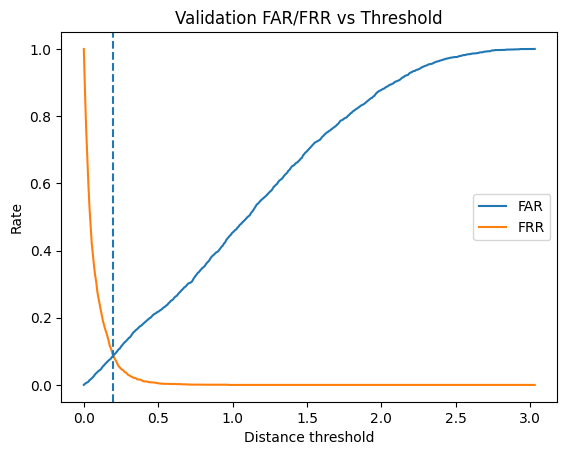

In [19]:
plt.figure()
plt.plot(thresholds, far, label="FAR")
plt.plot(thresholds, frr, label="FRR")
plt.axvline(best_t, linestyle="--")
plt.title("Validation FAR/FRR vs Threshold")
plt.xlabel("Distance threshold")
plt.ylabel("Rate")
plt.legend()
plt.show()
